# 🏆 Predicting Loan Payback - Playground Series S5E11
**Author:** Rishabh Kumar Kannaujiya  
**Date:** Nov 2025

## 1. Introduction
In this notebook, we tackle the **Playground Series Season 5, Episode 11** competition. The goal is to predict the probability of a borrower paying back a loan (Binary Classification).

**Approach:**
1. **EDA & Preprocessing:** Handling missing values, checking imbalance, and encoding categorical features.
2. **Modeling:** Training three Gradient Boosting giants: **XGBoost**, **LightGBM**, and **CatBoost**.
3. **Ensembling:** Combining predictions using a Weighted Average to maximize the **ROC AUC** score.

## 2. Setup and Data Loading

Here we will import the necessary libraries and load the training and testing datasets.

In [ ]:
!pip install optuna-integration[lightgbm]

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import optuna

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder

from lightgbm import LGBMClassifier
from lightgbm import early_stopping
from optuna.integration import LightGBMPruningCallback


from xgboost import XGBClassifier
from optuna.integration import XGBoostPruningCallback

from catboost import CatBoostClassifier
from catboost import Pool
from optuna.integration import CatBoostPruningCallback


In [5]:
warnings.filterwarnings('ignore')

In [6]:
train_df = pd.read_csv('/kaggle/input/playground-series-s5e11/train.csv')
test_df = pd.read_csv('/kaggle/input/playground-series-s5e11/test.csv')
submission_df = pd.read_csv('/kaggle/input/playground-series-s5e11/sample_submission.csv')

In [7]:
train_df.shape

(593994, 13)

In [8]:
test_df.shape

(254569, 12)

In [9]:
train_df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [10]:
train_df.columns.tolist()

['id',
 'annual_income',
 'debt_to_income_ratio',
 'credit_score',
 'loan_amount',
 'interest_rate',
 'gender',
 'marital_status',
 'education_level',
 'employment_status',
 'loan_purpose',
 'grade_subgrade',
 'loan_paid_back']

## 3. Exploratory Data Analysis (EDA)
We need to understand the distribution of the target variable and identify any missing data. We also drop the `id` column as it carries no predictive value.

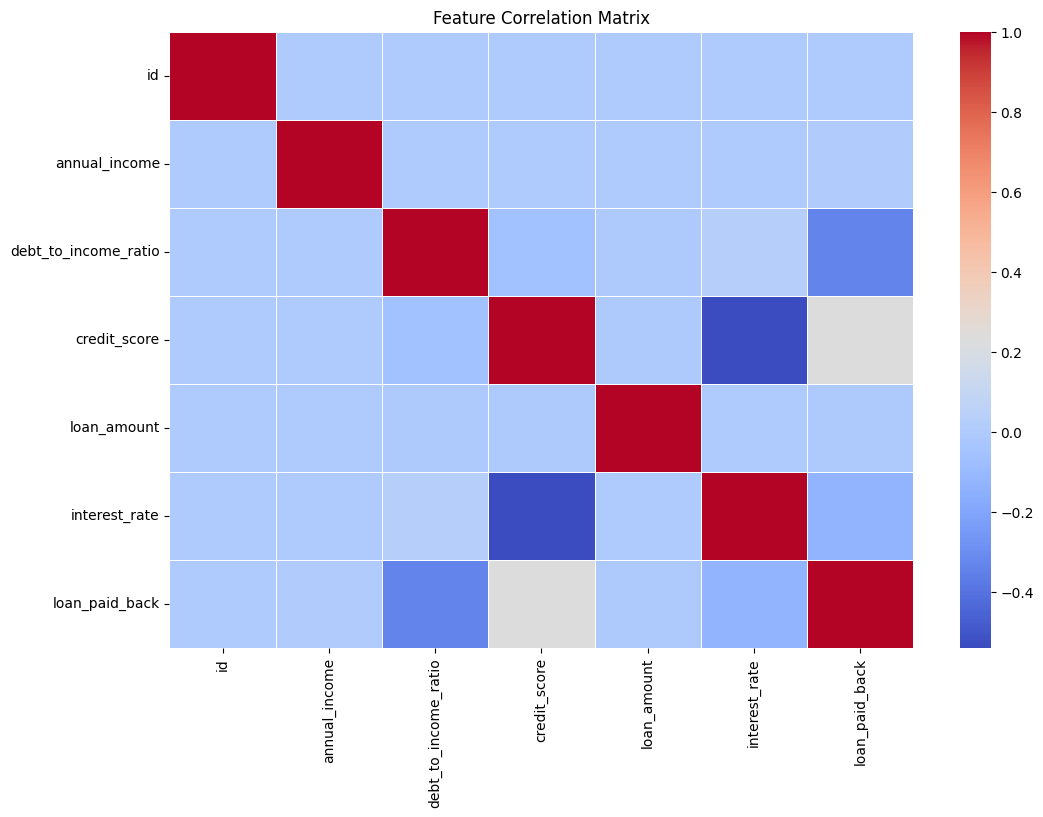

In [11]:
plt.figure(figsize=(12, 8))

# Selecting only numerical columns for correlation
numerical_data = train_df.select_dtypes(include=[np.number])
corr = numerical_data.corr()

sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

In [12]:
target = 'loan_paid_back'
print('Target Distribution:')
train_df[target].value_counts(normalize=True)

Target Distribution:


loan_paid_back
1.0    0.79882
0.0    0.20118
Name: proportion, dtype: float64

In [13]:
print('Missing Values in Train:')
train_df.isnull().sum()

Missing Values in Train:


id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

In [14]:
if 'id' in train_df.columns:
    train_df = train_df.drop(columns=['id'])
    test_df = test_df.drop(columns=['id'])

## 4. Advanced Feature Engineering

In [15]:
def create_features(df):

    # 1. Loan to Income Ratio (How heavy is the loan compared to their salary?)
    if 'loan_amount' in df.columns and 'annual_income' in df.columns:
        df['loan_to_income'] = df['loan_amount'] / (df['annual_income'] + 1)
    
    # 2. Monthly Burden (What % of monthly check goes to this loan?)
    if 'installment' in df.columns and 'annual_income' in df.columns:
        df['monthly_burden'] = df['installment'] / ((df['annual_income'] / 12) + 1)
        
    # 3. Total Interest Cost
    if 'loan_amount' in df.columns and 'interest_rate' in df.columns:
        df['total_interest_cost'] = df['loan_amount'] * df['interest_rate']

    # 4. Log Transform for Income (Helps with outliers)
    if 'annual_income' in df.columns:
        df['log_income'] = np.log1p(df['annual_income'])
        
    return df

# Apply to both Train and Test
print("Engineering new features...")
train_df = create_features(train_df)
test_df = create_features(test_df)
print("New features created.")
display(train_df.head())

Engineering new features...
New features created.


,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,loan_to_income,total_interest_cost,log_income
0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0,0.086091,34563.5014,10.287695
1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0,0.207748,59342.8520,10.003741
2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0,0.343073,165970.2640,10.811085
3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0,0.099926,75387.9280,10.754904
4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0,0.477864,124403.0303,10.146344


## 5. Preprocessing
### 5.1 Missing Values
We impute missing values to ensure our models run smoothly:
* **Numerical columns:** Filled with the **Median**.
* **Categorical columns:** Filled with the **Mode** (most frequent value).

In [16]:
cat_cols = [i for i in train_df.columns if train_df[i].dtype == 'object' and i != target]
num_cols = [i for i in train_df.columns if train_df[i].dtype != 'object' and i != target]

In [17]:
print('Categorical Columns:-', cat_cols, '\n\n', 'Number Columns:-', num_cols)

Categorical Columns:- ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade'] 

 Number Columns:- ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'loan_to_income', 'total_interest_cost', 'log_income']


In [18]:
print('lenght of cat_cols:', len(cat_cols))
print('lenght of num_cols:', len(num_cols))

lenght of cat_cols: 6
lenght of num_cols: 8


### 5.2 Label Encoding
Machine learning models require numerical input. We will use **Label Encoding** to convert categorical text columns into unique integers.

In [19]:
# 1. Fill Missing Values Globally
for col in num_cols:
    median_val = train_df[col].median()
    train_df[col] = train_df[col].fillna(median_val)
    test_df[col] = test_df[col].fillna(median_val)

# 2. Encode the ENTIRE train_df (so X gets the numbers later)
ordinal_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# This updates train_df directly!
train_df[cat_cols] = ordinal_enc.fit_transform(train_df[cat_cols].astype(str))
test_df[cat_cols] = ordinal_enc.transform(test_df[cat_cols].astype(str))

# 3. Create X (Now it will contain numbers because train_df is encoded)
X = train_df.drop(columns=[target])
y = train_df[target]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### 5.3 Optuna Tuning

In [20]:
FOLDS = 5
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)

In [21]:
# # for XGB Optuna
# def objective(trial):
#     params = {
#         'n_estimators': 5000,
#         'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
#         'max_depth': trial.suggest_int('max_depth', 3, 12),
#         'subsample': trial.suggest_float('subsample', 0.5, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
#         'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
#         'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
#         'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
#         'gamma': trial.suggest_float('gamma', 0, 5),
        
#         # GPU Settings
#         'device': 'cuda',
#         'tree_method': 'hist',
        
#         'objective': 'binary:logistic',
#         'eval_metric': 'auc',
#         'n_jobs': -1,
#         'random_state': 42,
#         'enable_categorical': False
#     }

#     cv_scores = []
    
#     # Print start of trial
#     print(f"--- Starting Trial {trial.number} ---")
    
#     for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
#         X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
#         y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
        
#         model = XGBClassifier(**params)
        
#         pruning_callback = XGBoostPruningCallback(trial, "validation_0-auc")
        
#         model.fit(
#             X_train_fold, y_train_fold,
#             eval_set=[(X_val_fold, y_val_fold)],
#             early_stopping_rounds=100,
#             callbacks=[pruning_callback],
#             verbose=False
#         )
        
#         preds = model.predict_proba(X_val_fold)[:, 1]
#         score = roc_auc_score(y_val_fold, preds)
#         cv_scores.append(score)
        
#         # --- PRINT PROGRESS HERE ---
#         print(f"Trial {trial.number} - Fold {fold+1} AUC: {score:.5f}")
    
#     mean_score = np.mean(cv_scores)
#     print(f"Trial {trial.number} Finished! Average AUC: {mean_score:.5f}\n")
#     return mean_score

# # 2. Optimization
# optuna.logging.set_verbosity(optuna.logging.INFO) # Ensure Optuna logs are on
# print("Starting XGBoost Optimization on GPU...")
# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=30)

# print("\nBest XGBoost Params:")
# print(study.best_params)
# print(f"Best CV AUC: {study.best_value:.5f}")

In [22]:
# # For LGBM Optuna
# def objective(trial):
#     params = {
#         # --- Model Complexity ---
#         'n_estimators': 5000,
#         'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
#         'num_leaves': trial.suggest_int('num_leaves', 20, 300),
#         'max_depth': trial.suggest_int('max_depth', 3, 15),
#         'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
#         'subsample': trial.suggest_float('subsample', 0.5, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
#         'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
#         'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        
#         # --- STRICT GPU P100 SETTINGS ---
#         'device': 'gpu',
#         'gpu_platform_id': 0,
#         'gpu_device_id': 0,
#         'gpu_use_dp': False,
#         'force_col_wise': True,
#         # -------------------------------
        
#         'objective': 'binary',
#         'metric': 'auc',
#         'n_jobs': -1,
#         'random_state': 42,
#         'verbose': -1
#     }

#     cv_scores = []
    
#     print(f"--- Starting Trial {trial.number} ---")
    
#     for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
#         X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
#         y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
        
#         model = LGBMClassifier(**params)
        
#         # Logic: Early stopping always. Pruning ONLY on Fold 1 (index 0).
#         callbacks_list = [early_stopping(100, verbose=False)]
#         if fold == 0:
#             callbacks_list.append(LightGBMPruningCallback(trial, "auc"))
        
#         try:
#             model.fit(
#                 X_train_fold, y_train_fold,
#                 eval_set=[(X_val_fold, y_val_fold)],
#                 eval_metric="auc",
#                 callbacks=callbacks_list
#             )
#         except optuna.exceptions.TrialPruned as e:
#             print(f"!!! Trial {trial.number} Pruned at Fold {fold+1} !!!")
#             raise e
#         except Exception as e:
#             # Catch GPU specific errors (e.g., if dataset is too small for GPU)
#             print(f"Error in Trial {trial.number}: {e}")
#             raise e
        
#         preds = model.predict_proba(X_val_fold)[:, 1]
#         score = roc_auc_score(y_val_fold, preds)
#         cv_scores.append(score)
        
#         print(f"Trial {trial.number} - Fold {fold+1} AUC: {score:.5f}")
    
#     mean_score = np.mean(cv_scores)
#     print(f"Trial {trial.number} Finished! Average AUC: {mean_score:.5f}\n")
    
#     return mean_score

# # --- Execution ---
# optuna.logging.set_verbosity(optuna.logging.INFO)
# print("Starting Strictly GPU-Optimized LightGBM...")

# # Run optimization
# study_lgbm = optuna.create_study(direction='maximize')
# study_lgbm.optimize(objective, n_trials=30) 

# print("\nBest LightGBM Params:")
# print(study_lgbm.best_params)
# print(f"Best CV AUC: {study_lgbm.best_value:.5f}")

In [23]:
# # For CatBoost Optuna
# def objective_catboost(trial):
#     params = {
#         # --- Model Complexity & Regularization ---
#         'iterations': 5000,
#         'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
#         'depth': trial.suggest_int('depth', 4, 10),
#         'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
#         'random_strength': trial.suggest_float('random_strength', 1e-9, 10.0, log=True),
#         'border_count': trial.suggest_int('border_count', 32, 255),
        
#         # --- GPU Specifics for P100 ---
#         'task_type': 'GPU',
#         'devices': '0', 
#         'bootstrap_type': 'Bernoulli', 
#         'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        
#         # --- Standard Settings ---
#         'loss_function': 'Logloss',
#         'eval_metric': 'AUC',
#         'random_seed': 42,
#         'verbose': False,
#         'early_stopping_rounds': 100
#     }

#     cv_scores = []
    
#     print(f"--- Starting Trial {trial.number} ---\n")
    
#     for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
#         X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
#         y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
        
#         model = CatBoostClassifier(**params)
        
#         model.fit(
#             X_train_fold, y_train_fold,
#             eval_set=(X_val_fold, y_val_fold),
#             use_best_model=True,
#             verbose=False 
#         )

#         preds = model.predict_proba(X_val_fold)[:, 1]
#         score = roc_auc_score(y_val_fold, preds)
#         cv_scores.append(score)
        
#         print(f"Trial {trial.number} - Fold {fold+1} AUC: {score:.5f}")
    
#     mean_score = np.mean(cv_scores)
#     print(f"Trial {trial.number} Finished! Average AUC: {mean_score:.5f}\n")
    
#     return mean_score

# # --- Run Optimization ---
# optuna.logging.set_verbosity(optuna.logging.INFO)
# print("Starting CatBoost Optimization on GPU P100...")

# study_cat = optuna.create_study(direction='maximize', study_name="CatBoost_Optimization")
# study_cat.optimize(objective_catboost, n_trials=30) 

# print("\nBest CatBoost Params:")
# print(study_cat.best_params)
# print(f"Best CV AUC: {study_cat.best_value:.5f}")

## 6. Model Training
### 6.1 XGBoost

We start with **XGBoost**, a powerful gradient boosting library known for its performance and speed. We use an 80/20 train-validation split to monitor the **AUC Score**.

In [24]:
# 1. Defining the Best Parameters found
best_params = {
    'learning_rate': 0.06306402264031599,
    'max_depth': 6,
    'subsample': 0.9877243257173147,
    'colsample_bytree': 0.9424086534559548,
    'min_child_weight': 4,
    'reg_lambda': 0.008595178377302507,
    'reg_alpha': 0.05542369465609152,
    'gamma': 0.2691485091993745,
    
    # Fixed Parameters for GPU
    'n_estimators': 5000,
    'device': 'cuda',
    'tree_method': 'hist',
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'n_jobs': -1,
    'random_state': 42,
    'enable_categorical': False
}

# 2. Retrain on all folds
print("Retraining Final XGBoost Model with Best Params...")

final_xgb_preds = np.zeros(len(test_df))
final_xgb_oof = np.zeros(len(X))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    model = XGBClassifier(**best_params)
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        early_stopping_rounds=100,
        verbose=0
    )
    
    # OOF Predictions (for scoring)
    val_p = model.predict_proba(X_val)[:, 1]
    final_xgb_oof[val_idx] = val_p
    
    # Test Predictions (for submission)
    final_xgb_preds += model.predict_proba(test_df)[:, 1] / FOLDS
    
    print(f"Fold {fold+1} Optimized AUC: {roc_auc_score(y_val, val_p):.5f}")

# 3. Check Final Score
final_cv_score = roc_auc_score(y, final_xgb_oof)
print(f"\nOverall Optimized XGBoost CV AUC: {final_cv_score:.5f}")

Retraining Final XGBoost Model with Best Params...
Fold 1 Optimized AUC: 0.92234
Fold 2 Optimized AUC: 0.92204
Fold 3 Optimized AUC: 0.92013
Fold 4 Optimized AUC: 0.92133
Fold 5 Optimized AUC: 0.92064

Overall Optimized XGBoost CV AUC: 0.92129


### 6.2 LightGBM (K-Fold Cross Validation)

Now, we will train **LightGBM**. It is highly efficient and often captures different patterns than XGBoost, which makes it excellent for ensembling.

In [25]:
# 1. Combining the Best Params from Optuna
lgbm_params = {
    'learning_rate': 0.11800628949217232,
    'num_leaves': 110,
    'max_depth': 5,
    'min_child_samples': 34,
    'subsample': 0.8554501523090093,
    'colsample_bytree': 0.507019653413801,
    'reg_alpha': 0.0922019636447731,
    'reg_lambda': 0.03375421066057399,
    
    # Fixed Params (from your objective function)
    'n_estimators': 5000,
    'objective': 'binary',
    'metric': 'auc',
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
    
    'device': 'gpu',
    'gpu_platform_id': 0,
    'gpu_device_id': 0,
    'gpu_use_dp': False,
    'force_col_wise': True
}

# 2. Initialize Arrays to store predictions
lgbm_oof_preds = np.zeros(len(X))
lgbm_test_preds = np.zeros(len(test_df))

In [26]:
print(f"Training Optimized LightGBM on {FOLDS} Folds...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    # Create Fold Data
    X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
    X_val_fold, y_val_fold = X.iloc[val_idx], y.iloc[val_idx]
    
    # Initialize Model
    model = LGBMClassifier(**lgbm_params)
    
    # Train
    model.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_val_fold, y_val_fold)],
        eval_metric="auc",
        callbacks=[early_stopping(stopping_rounds=100, verbose=False)]
    )
    
    # Generate OOF Predictions (Validation)
    val_preds = model.predict_proba(X_val_fold)[:, 1]
    lgbm_oof_preds[val_idx] = val_preds
    
    # Generate Test Predictions (Average them)
    lgbm_test_preds += model.predict_proba(test_df)[:, 1] / FOLDS
    
    # Print Score
    fold_score = roc_auc_score(y_val_fold, val_preds)
    print(f"Fold {fold+1} AUC: {fold_score:.5f}")

# Calculate Overall CV Score
overall_cv_score = roc_auc_score(y, lgbm_oof_preds)
print(f"\nOverall Optimized LightGBM CV AUC: {overall_cv_score:.5f}")

Training Optimized LightGBM on 5 Folds...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Fold 1 AUC: 0.92368
Fold 2 AUC: 0.92332
Fold 3 AUC: 0.92205
Fold 4 AUC: 0.92310
Fold 5 AUC: 0.92219

Overall Optimized LightGBM CV AUC: 0.92286


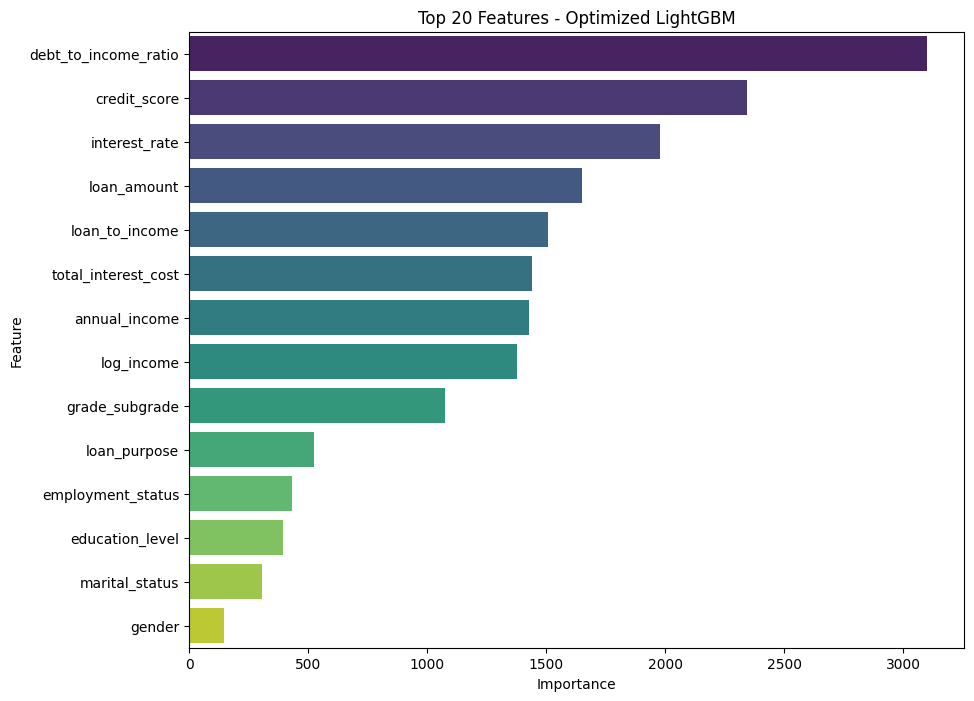

In [27]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance.head(20), palette='viridis')
plt.title('Top 20 Features - Optimized LightGBM')
plt.show()

### 6.3 CatBoost

Now, we will train **CatBoost**. This model is particularly robust and handles categorical relationships very well, often providing high stability.

In [29]:
best_cat_params = {
    'learning_rate': 0.13920677408646712,
    'depth': 5,
    'l2_leaf_reg': 0.5223157283384439,
    'random_strength': 3.690512444785991e-08,
    'border_count': 252,
    'subsample': 0.652240898735347,
    
    # Fixed GPU Params
    'iterations': 5000,
    'task_type': 'GPU',
    'devices': '0',
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'random_seed': 42,
    'verbose': 0,
    'early_stopping_rounds': 100,
    'bootstrap_type': 'Bernoulli' 
}


In [30]:
print("Retraining Final CatBoost Model with Best Params...")

cat_oof_preds = np.zeros(len(X))
cat_test_preds = np.zeros(len(test_df))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    model = CatBoostClassifier(**best_cat_params)
    
    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        use_best_model=True
    )
    
    # OOF Predictions
    val_p = model.predict_proba(X_val)[:, 1]
    cat_oof_preds[val_idx] = val_p
    
    # Test Predictions
    cat_test_preds += model.predict_proba(test_df)[:, 1] / FOLDS
    
    print(f"Fold {fold+1} AUC: {roc_auc_score(y_val, val_p):.5f}")

print(f"\nOverall Optimized CatBoost CV AUC: {roc_auc_score(y, cat_oof_preds):.5f}")

Retraining Final CatBoost Model with Best Params...


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 1 AUC: 0.92362


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 2 AUC: 0.92366


...

Fold 3 AUC: 0.92152


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 4 AUC: 0.92275


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 5 AUC: 0.92186

Overall Optimized CatBoost CV AUC: 0.92268


## 7. Ensembling & Submission
### 7.1 Weighted Ensemble

* To improve generalization and reduce overfitting, we will combine the predictions of all three models.
* Based on validation scores, we assign weights to each model to create the final model prediction.

In [31]:
ensemble_oof = (lgbm_oof_preds * 0.4) + (cat_oof_preds * 0.4) + (final_xgb_oof * 0.2)
ensemble_score = roc_auc_score(y, ensemble_oof)

print(f"LightGBM AUC: {roc_auc_score(y, lgbm_oof_preds):.5f}")
print(f"CatBoost AUC: {roc_auc_score(y, cat_oof_preds):.5f}")
print(f"XGBoost AUC:  {roc_auc_score(y, final_xgb_oof):.5f}")
print("-" * 30)
print(f"Ensemble AUC: {ensemble_score:.5f}")

LightGBM AUC: 0.92286
CatBoost AUC: 0.92268
XGBoost AUC:  0.92129
------------------------------
Ensemble AUC: 0.92326


In [32]:
final_test_predictions = (lgbm_test_preds * 0.4) + (cat_test_preds * 0.4) + (final_xgb_preds * 0.2)

submission_df[target] = final_test_predictions
submission_df.to_csv('submission.csv', index=False)

print("Success! Final 'submission.csv' is ready.")

Success! Final 'submission.csv' is ready.
